<a href="https://colab.research.google.com/github/harishraghavhr7/ML-models_numpy/blob/main/knn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Shape of X: (1797, 64)
Shape of y: (1797,)

Best Parameters:
{'metric': 'euclidean', 'n_neighbors': np.int64(1), 'weights': 'uniform'}

Best Cross Validation Score:
0.9902463221060781

Test Accuracy:
0.9861111111111112

Confusion Matrix:
[[36  0  0  0  0  0  0  0  0  0]
 [ 0 36  0  0  0  0  0  0  0  0]
 [ 0  0 35  0  0  0  0  0  0  0]
 [ 0  0  0 37  0  0  0  0  0  0]
 [ 0  0  0  0 36  0  0  0  0  0]
 [ 0  0  0  0  0 37  0  0  0  0]
 [ 0  0  0  0  0  0 36  0  0  0]
 [ 0  0  0  0  0  0  0 36  0  0]
 [ 0  3  0  0  0  0  0  0 32  0]
 [ 0  0  0  0  1  0  0  0  1 34]]


<Figure size 1000x800 with 0 Axes>

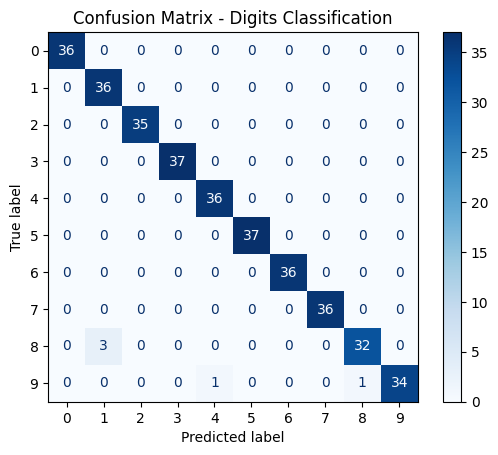


Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        36
           1       0.92      1.00      0.96        36
           2       1.00      1.00      1.00        35
           3       1.00      1.00      1.00        37
           4       0.97      1.00      0.99        36
           5       1.00      1.00      1.00        37
           6       1.00      1.00      1.00        36
           7       1.00      1.00      1.00        36
           8       0.97      0.91      0.94        35
           9       1.00      0.94      0.97        36

    accuracy                           0.99       360
   macro avg       0.99      0.99      0.99       360
weighted avg       0.99      0.99      0.99       360



In [ ]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)


digits = load_digits()

X = digits.data
y = digits.target

print("Shape of X:", X.shape)
print("Shape of y:", y.shape)



X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)



param_grid = {
    'n_neighbors': np.arange(1, 21),
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan']
}

grid = GridSearchCV(
    KNeighborsClassifier(),
    param_grid,
    cv=5,
    scoring='accuracy'
)

grid.fit(X_train, y_train)

print("\nBest Parameters:")
print(grid.best_params_)

print("\nBest Cross Validation Score:")
print(grid.best_score_)



best_knn = grid.best_estimator_

best_knn.fit(X_train, y_train)



y_pred = best_knn.predict(X_test)



accuracy = accuracy_score(y_test, y_pred)

print("\nTest Accuracy:")
print(accuracy)


cm = confusion_matrix(y_test, y_pred)

print("\nConfusion Matrix:")
print(cm)


plt.figure(figsize=(10, 8))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=digits.target_names
)

disp.plot(cmap='Blues')

plt.title("Confusion Matrix - Digits Classification")
plt.show()



report = classification_report(y_test, y_pred)

print("\nClassification Report:")
print(report)